In [49]:
import pandas as pd 
import os
import platform
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
# set 42 for pdf 
plt.rcParams['pdf.fonttype'] = 42 
plt.rcParams['ps.fonttype'] = 42


# Todo micha
* Summarise the frequency results for myself 
* Get the code working locally (for me) 
* Make the plots nicer, and readable 
* Consolidate the potential explanations, write summary for paper, we consider: 
- write remaining todo's over coming weeks, with timeline, we need to push this, 
* TACL is the outlet we should try, and after that EMNLP but the arxiv will be available 



In [50]:
## get data


## get data

In [3]:
micha=True
if "pop-os" in platform.node():
    ROOT = r"/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/"
elif micha:
    ROOT="/Users/Micha/Library/CloudStorage/OneDrive-UvA/Documents/Projects/in_progress/abishek_startingsmall/code/main/ss-llm/nanoGPT"
else:
    ROOT = r'/gpfs/home4/athamma/repo/ss-llm/nanoGPT/'
    
    
TOKENIZER_ROOT = os.path.join(ROOT, "data")
OUT_ROOT = os.path.join(ROOT, "output_dump")
RESULTS_ROOT = os.path.join(ROOT, "results")

SQL_DB = os.path.join(RESULTS_ROOT, "results.db")


def create_connection_cursor(db_file):
    """
    Create a database connection to the SQLite database specified by the db_file

    Args:
        db_file (str): database file

    Returns:
        Connection object or None
    """
    conn = sqlite3.connect(db_file)
    c = conn.cursor()
    return conn, c

conn, c = create_connection_cursor(SQL_DB)

# Big cell with plotting funcs

In [4]:
#Plotting Functions 

def fmt_boot_pval(pval,n_boots=10e4,scientific=False) -> str:
    """convertr bootstrap pvalues to expression that takes into account precision
    (e.g. p=0 will become p < x, with x being determined by number of bootstraps)"""
    if scientific:
        p_str= f'p={pval}' if pval>0 else f'p < {round(1/float(n_boots),int(np.log10(n_boots)+1))}'
    else:
        if pval>0:p_str=f'p={pval}'
        else:p_str='p < {atleast:.{decim}f}'.format(atleast=1/float(n_boots),decim=int(np.log10(n_boots)))
    return(p_str)

def bootstrap_t_onesample(samps_in,pop_mean=0,tail='2s',n_boots=10e4,seed=123):
    """one-sample (paired) bootstrap t-test; returns p-value only

    in:
    - samps: nd.array, shape(n_samples)
        datapoints
    - pop_mean: float, Default=0
        mean to test against
    - tail: str, default: '2s'
        options: '2s','l','r' (for two-tailed,left or right-tailed)
    - n_boots: int; default=10e3
        number of bootstraps (determines precision)

    out:
    -pval: float
        fraction of instances where simulated null distribution returns
        test statistic that is at least as extreme as emprical test stat.
    see also:
    - fmt_boot_pval, function to format the pvalues, changes p=0 into P < (1/n_boots) statement
    dependencies: bootstrap from astropy
    """
    if seed is not None:
      np.random.seed(seed)
    # test stat
    t_func=lambda x,dim:(x.mean(dim)-pop_mean)/(x.std(dim)/np.sqrt(x.shape[dim]))
    # make null distribution
    null_boot_test=t_func(bootstrap(samps_in-samps_in.mean(0)+pop_mean,bootnum=int(n_boots)),1)
    emp_test=t_func(samps_in,0)
    # return p-value as probability of obtaining a test stat at least as extreme under the null
    if tail in ['2s','two','both']:
        left_pval=np.mean(null_boot_test<emp_test)
        right_pval=np.mean(null_boot_test>emp_test)
        return(2*min(left_pval,right_pval))
    elif tail.lower() in ['l','left']:
        return(np.mean(null_boot_test<emp_test))
    elif tail.lower() in ['r','right']:
        return(np.mean(null_boot_test>emp_test))
    else:
        raise ValueError('tail not recognised!')

def bootstrap_analysis(data, pop_mean=0, tail='2s', n_boots=10000, seed=123):
    """
    Perform bootstrap analysis including one-sample t-test and compute 95% CI for the mean.

    Parameters:
    - data (array-like): Sample data.
    - pop_mean (float): Mean to test against.
    - tail (str): Type of the test ('2s' for two-tailed, 'l' for left-tailed, 'r' for right-tailed).
    - n_boots (int): Number of bootstrap samples.
    - seed (int): Seed for the random number generator.

    Returns:
    - dict: Contains the mean, 95% CI for the mean, and formatted p-value.
    """
    if seed is not None:
      np.random.seed(seed)

    # Compute the p-value using the provided function
    p_value = bootstrap_t_onesample(data, pop_mean, tail, n_boots, seed)

    # Format the p-value
    formatted_p_value = fmt_boot_pval(p_value, n_boots)

    # Calculate the sample mean
    sample_mean = np.mean(data)

    # Generate bootstrap samples for the CI of the mean
    bootstrap_samples = bootstrap(data, bootnum=n_boots, bootfunc=np.mean)
    ci_lower, ci_upper = np.percentile(bootstrap_samples, [2.5, 97.5])

    # Compile results
    results = {
        'mean                    ': sample_mean,
        '95%_CI around mean      ': (ci_lower, ci_upper),
        'bootstrap-t-test p_value': formatted_p_value
    }

    return results

def bootstrap(data, bootnum=1000, samples=None, bootfunc=None, seed=False):
    """Performs bootstrap resampling on numpy arrays. (FUNCTION FROM ASTROPY)

    Bootstrap resampling is used to understand confidence intervals of sample
    estimates. This function returns versions of the dataset resampled with
    replacement ("case bootstrapping"). These can all be run through a function
    or statistic to produce a distribution of values which can then be used to
    find the confidence intervals.

    Parameters
    ----------
    data : numpy.ndarray
        N-D array. The bootstrap resampling will be performed on the first
        index, so the first index should access the relevant information
        to be bootstrapped.
    bootnum : int, optional
        Number of bootstrap resamples
    samples : int, optional
        Number of samples in each resample. The default `None` sets samples to
        the number of datapoints
    bootfunc : function, optional
        Function to reduce the resampled data. Each bootstrap resample will
        be put through this function and the results returned. If `None`, the
        bootstrapped data will be returned

    Returns
    -------
    boot : numpy.ndarray

        If bootfunc is None, then each row is a bootstrap resample of the data.
        If bootfunc is specified, then the columns will correspond to the
        outputs of bootfunc.

    """
    if seed != False:
        np.random.seed(seed)

    if samples is None:
        samples = data.shape[0]

    # make sure the input is sane
    if samples < 1 or bootnum < 1:
        raise ValueError("neither 'samples' nor 'bootnum' can be less than 1.")

    if bootfunc is None:
        resultdims = (bootnum,) + (samples,) + data.shape[1:]
    else:
        # test number of outputs from bootfunc, avoid single outputs which are
        # array-like
        try:
            resultdims = (bootnum, len(bootfunc(data)))
        except TypeError:
            resultdims = (bootnum,)

    # create empty boot array
    boot = np.empty(resultdims)

    for i in range(bootnum):
        bootarr = np.random.randint(low=0, high=data.shape[0], size=samples)

#         if seed != False: print(bootarr)
        if bootfunc is None:
            boot[i] = data[bootarr]
        else:
            boot[i] = bootfunc(data[bootarr])

    return boot


def add_sig_stars(ax, df, name_col, pval_col, height_factor=1.1, fontsize=14):
    """Add significance stars to seaborn plot based on p-values."""
    ymin, ymax = ax.get_ylim()

    def pval_to_stars(pval):
#         Using narrow no-break space (\u202f) between stars for tighter spacing
        pval_c = float(pval.split('=')[1]) if 'p=' in pval else float(pval.split('<')[1])
        if pval_c < 0.001: return '*\u200a*\u200a*'
        elif pval_c < 0.01: return '*\u200a*'
        elif pval_c < 0.05: return '*'
        return 'ns'

    xticks = ax.get_xticks()
    xticklabels = [label.get_text() for label in ax.get_xticklabels()]
    name_to_pos = dict(zip(xticklabels, xticks))
    print(df)
    for _, row in df.iterrows():
        if row[name_col] in name_to_pos:
            x_pos = name_to_pos[row[name_col]]
            stars = pval_to_stars(row[pval_col])
            y_pos = ymax + (ymax - ymin) * (height_factor - 1)
            ax.text(x_pos, y_pos, stars,
                  horizontalalignment='center',
                  verticalalignment='center',
                  fontweight='semibold',
                  fontsize=fontsize,
                  family='DejaVu Sans')  # or try 'Arial'

    ax.set_ylim(ymin, ymax + (ymax - ymin) * (height_factor - 1) * 1.2)

def annotate_plot(ax, x1, x2, y, h, asterisk, h_factor=0.9):

    #Ax = ax object
    #x1, x2 = x-coordinates of the bars, give absolute bar id location 0 to n_bar-1
    #y = y-coordinate of the bar, actual value in y axis where you want bar to be placed
    #h = height of the bar
    #asterisk = string to be placed on top of the bar, *,**,***, etc.
    
    if asterisk == '':
        return
    
    #Use annotate pairs to add bars on top of specific columns
    ax = plt.gca() if ax is None else ax
    
    #Calculate y and h based on the data
    # y as 80% of max y limit
    # h as 5% of max y limit
    print("Old y, h", y, h)
    print("Y lim values", ax.get_ylim())
    y = ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * h_factor
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.03

    print("New y, h", y, h)



    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
    
    asterisk_map = {
        "*": "*",
        "**": '*\u200a*',
        "***": '*\u200a*\u200a*'
    }

    if asterisk in ['*', '**', '***']:
        ax.text((x1+x2)*.5, y+h, asterisk_map[asterisk], ha='center', va='bottom', color='black', fontweight='semibold',
                  family='DejaVu Sans')
    else:
        ax.text((x1+x2)*.5, y+h*2, "ns", ha='center', va='bottom', color='black', 
                  fontweight='semibold',
                  family='DejaVu Sans')

def get_asterisk_map(pval):
    pval_c = float(pval.split('=')[1]) if 'p=' in pval else float(pval.split('<')[1])
    if pval_c < 0.001:
        return '***'
    elif pval_c < 0.01:
        return '**'
    elif pval_c < 0.05:
        return '*'
    else:
        return pval

def connect_dots(ax_obj,alpha=.4,col='grey', linewidth=2):
    """ for a given ax_object (from scatterplot or sns.stripplot or the like)
    connect the dots (arbtirary number of columns)"""
    cs=ax_obj.collections
    xcoords=np.vstack([this_cs.get_offsets()[:,0] for this_cs in cs]).T
    ycoords=np.vstack([this_cs.get_offsets()[:,1] for this_cs in cs]).T
    for (xcoord,ycoord) in zip(xcoords,ycoords):
        ax_obj.plot(xcoord,ycoord,alpha=alpha,color=col,linewidth=linewidth)

    return(ax_obj)

#ib = individual blimp
#Different way to connect dots for individual blimp scores, because pair-wise comp 

def connect_dots_ib(ax_obj,alpha=.4,col='grey', linewidth=2):
    """ for a given ax_object (from scatterplot or sns.stripplot or the like)
    connect the dots (arbtirary number of columns)"""
    cs=ax_obj.collections
    xcoords=np.vstack([this_cs.get_offsets()[:,0] for this_cs in cs]).T
    ycoords=np.vstack([this_cs.get_offsets()[:,1] for this_cs in cs]).T
    for (xcoord,ycoord) in zip(xcoords,ycoords):
        
        xcoord = [xcoord[0::2], xcoord[1::2]]
        ycoord = [ycoord[0::2], ycoord[1::2]]
        ax_obj.plot(xcoord,ycoord,alpha=alpha,color=col,linewidth=linewidth)

    return(ax_obj)

def annotate_plot_ib(ax, x1, y_frac, h_frac, asterisk):
    #Ax = ax object
    #x1, x2 = x-coordinates of the bars, give absolute bar id location 0 to n_bar-1
    #y = y-coordinate of the bar, actual value in y axis where you want bar to be placed
    #h = height of the bar
    #asterisk = string to be placed on top of the bar, *,**,***, etc.

    if asterisk == '':
        return

    #Use annotate pairs to add bars on top of specific columns
    ax = plt.gca() if ax is None else ax

    #Calculate y and h based on the data
    y = ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * y_frac
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * h_frac

    #ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')
    #Given a x1, plot within its hue
    ax.plot([x1-0.2, x1-0.2, x1+0.2, x1+0.2], [y, y+h, y+h, y], lw=1.5, c='black')
    asterisk_map = {
        "*": "*",
        "**": '*\u200a*',
        "***": '*\u200a*\u200a*'
    }
    if asterisk in ['*', '**', '***']:
        ax.text((x1+x1)*.5, y+h, asterisk_map[asterisk], ha='center', va='bottom', color='black', fontweight='semibold',
                  family='DejaVu Sans')
    else:
        ax.text((x1+x1)*.5, y+h*2, "ns", ha='center', va='bottom', color='black', fontweight='semibold',
                  family='DejaVu Sans')

def annotate_given_colid_ib(ax, col_id1, plot_data, y_frac, h_frac, conditional_map):

    col_names = [tick.get_text() for tick in ax.get_xticklabels()]
    col_names = {i: col_name for i, col_name in enumerate(col_names)}

    #Annotate within hue 
    #res = annotate_given_colid(ax, 0, 1, plot_data, 90, 2, "score", col_names[0])

    stats_test_subset = plot_data[plot_data["condition"].isin(conditional_map.values())][["condition", "seed", "score"]][plot_data["blimp_task"] == col_names[col_id1]]

    pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
    #print(pairwise_diff)
    res = bootstrap_analysis(pairwise_diff.values,)#alternatively, do: tail='r' to test for delta>0 (one-sided)
    #print(res)
    annotate_plot_ib(ax, col_id1, y_frac, h_frac, get_asterisk_map(res['bootstrap-t-test p_value']))
    
    return res

def annotate_given_colid_ib_gen(ax, plot_data, y_frac, h_frac, x_col, pivot_col, value_column="score"):

    # col_names = [tick.get_text() for tick in ax.get_xticklabels()]
    # col_names = {i: col_name for i, col_name in enumerate(col_names)}

    # #Annotate within hue 
    # #res = annotate_given_colid(ax, 0, 1, plot_data, 90, 2, "score", col_names[0])

    # stats_test_subset = plot_data[plot_data["condition"].isin(conditional_map.values())][["condition", "seed", "score"]][plot_data["blimp_task"] == col_names[col_id1]]

    # pairwise_diff = stats_test_subset.groupby('seed').apply(lambda x: x[x['condition']==list(conditional_map.values())[1]]["score"].values[0] - x[x['condition']==list(conditional_map.values())[0]]["score"].values[0])
    # #print(pairwise_diff)
    # res = bootstrap_analysis(pairwise_diff.values,)#alternatively, do: tail='r' to test for delta>0 (one-sided)
    # #print(res)
    # annotate_plot_ib(ax, col_id1, y_frac, h_frac, get_asterisk_map(res['bootstrap-t-test p_value']))
    
    for i, txt in enumerate(plot_data[x_col].unique()):
        stats_test_subset = plot_data[plot_data[x_col] == txt]
        #print("Stats test subset \n ", stats_test_subset)
        #Calculate Pairwise differences for the subset of the data where x_col, and pairwise difference of the value_column
        pairwise_diff = stats_test_subset.pivot(index='seed', columns=pivot_col, values=value_column).dropna()
        #print("K1 \n ", pairwise_diff)
        pairwise_diff = pairwise_diff[pairwise_diff.columns[0]] - pairwise_diff[pairwise_diff.columns[1]]
        #print("k2 \n", pairwise_diff)
        
        res = bootstrap_analysis(pairwise_diff.values,)
        annotate_plot_ib(ax, i, y_frac, h_frac, get_asterisk_map(res['bootstrap-t-test p_value']))

    return res


#add variable for comparison data (Validation Loss or BLIMP scores or Reading Time)
def annotate_given_colid(ax, col_id1, col_id2, plot_data, y, h, plotcolname, group_by="seed", h_factor=0.9):
    col_names = [tick.get_text() for tick in ax.get_xticklabels()]
    col_names = {i: col_name for i, col_name in enumerate(col_names)}
    #print(col_names)
    #Using the column names, get the data for each condition #Just do for 0,1 for now
    #print("Comparing", col_names[col_id1], "and", col_names[col_id2])
    stats_test_subset = plot_data[plot_data["condition"].isin([col_names[col_id1], col_names[col_id2]])]
    #Get pairwise differences
    pairwise_diff = stats_test_subset.groupby(group_by).apply(lambda x: x[x['condition']==col_names[col_id1]][plotcolname].values[0] - x[x['condition']==col_names[col_id2]][plotcolname].values[0])
    #print(pairwise_diff)

    # perform bootstrap-t-test analysis on pairwise values (https://open.lnu.se/index.php/metapsychology/article/view/2058)
    res = bootstrap_analysis(pairwise_diff.values,)#alternatively, do: tail='r' to test for delta>0 (one-sided)
    #print(res)
    #Use results to annotate the plot
    annotate_plot(ax, col_id1, col_id2, y, h, get_asterisk_map(res['bootstrap-t-test p_value']), h_factor=h_factor)

    # #Add significance stars
    # add_sig_stars(ax, pd.DataFrame({"condition": [col_names[col_id1], col_names[col_id2], col_names[col_id1]], "p-value": [res['bootstrap-t-test p_value'], res['bootstrap-t-test p_value'], res['bootstrap-t-test p_value']]}), "condition", "p-value")
    return res


# Actuall stuffs 

In [33]:
from pathlib import Path

# def save_matplot_fig(fig, save_name, dpi=300, folders_path = None):
    
#     #path = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/log_analyser'
#     root_path = Path(ROOT)+ Path(r'/eval/additional_analysis/reading_time_detailed')
#     #root_path = r'/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/results/final_paper_stuff/results_figs_fin'
#     if folders_path is not None:
#         path = os.path.join(root_path, folders_path)
#     else:
#         path = root_path
#     path = Path(path)
#     path.mkdir(parents=True, exist_ok=True)
    
#     path = os.path.join(path, save_name)
     
#     #If extension is not provided, add it as pdf
#     if not path.endswith(".pdf"):
#         if not (path.endswith(".png") or path.endswith(".jpg") or path.endswith(".jpeg")):
#             path = path + ".png"

#     inp = input(f"Saving figure to {path}. Press Enter to continue, or type 'n' to cancel: ")
#     if inp.lower() == 'n':
#         print("Figure not saved")
#         return
#     fig.savefig(path, dpi=dpi, bbox_inches='tight')
    

def save_matplot_fig(fig, save_name, dpi=300, folders_path = None):
    """Saves a matplotlib figure, fixing the path joining, extremely redundant function hahah micha."""

    # Use '/' for joining pathlib.Path objects instead of '+'
    root_path = Path(ROOT) / 'eval/additional_analysis/reading_time_detailed'
    # root_path = Path(ROOT) / 'results/final_paper_stuff/results_figs_fin' # Alternative

    if folders_path is not None:
        # os.path.join works with Path objects (since Py 3.6) and returns a string
        dir_path_str = os.path.join(root_path, folders_path)
        # Convert back to Path object for mkdir
        dir_path = Path(dir_path_str)
    else:
        # If no subfolders, use the root_path directly (already a Path object)
        dir_path = root_path

    # Create the directory
    dir_path.mkdir(parents=True, exist_ok=True)

    # Create the full file path string using os.path.join
    # It correctly handles joining Path objects and strings, returning a string
    full_file_path_str = os.path.join(dir_path, save_name)

    # Check/add extension using string methods on the resulting path string
    # Using lower() for case-insensitivity
    known_extensions = (".pdf", ".png", ".jpg", ".jpeg")
    if not full_file_path_str.lower().endswith(known_extensions):
        full_file_path_str += ".png" # Default to .png

    # Confirmation prompt
    # try:
    #     inp = input(f"Saving figure to {full_file_path_str}. Press Enter to continue, or type 'n' to cancel: ")
    #     if inp.strip().lower() == 'n':
    #         print("Figure not saved.")
    #         return
    # except EOFError:
    #     print("Non-interactive mode. Saving automatically.")
        # Pass # Or handle non-interactive saving differently if needed

    # Save the figure (savefig accepts string paths)
    try:
        fig.savefig(full_file_path_str, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved: {full_file_path_str}")
    except Exception as e:
        print(f"Error saving figure to {full_file_path_str}: {e}")    
    


In [6]:
words_df = pd.read_sql_query("SELECT * FROM WordDetails", conn)
words_df

,WordUID,Word,CharacterLength,LogFrequencies,QuintilesA1,QuintilesA2,QuintilesA3,SpacyTokenProb
0,1,if,2,5.256744,4,4,4,-5.763590
1,2,you,3,6.329340,4,4,4,-4.373791
2,3,were,4,4.928421,4,4,4,-6.673175
3,4,to,2,6.063172,4,4,4,-3.856022
4,5,journey,7,3.007748,3,3,3,-11.295086
...,...,...,...,...,...,...,...,...
10134,10135,disks,5,1.913814,2,1,2,-12.883524
10135,10136,stored,6,2.230449,2,2,3,-11.588490
10136,10137,embrace,7,2.587711,3,2,2,-11.984515
10137,10138,coincides,9,1.146128,1,0,1,-14.459026


In [7]:
story_words_df = pd.read_sql_query("SELECT * FROM Story", conn)
story_words_df

,StoryWordID,CorpusID,StoryID,WordID,Word,WordUID,POSTag,NERTag
0,1,1,1,1,If,1,ADP,
1,2,1,1,2,you,2,PRON,
2,3,1,1,3,were,3,VERB,
3,4,1,1,4,to,4,PRT,
4,5,1,1,5,journey,5,VERB,
...,...,...,...,...,...,...,...,...
61752,61753,2,20,2449,countries,5644,NOUN,
61753,61754,2,20,2450,are,286,VERB,
61754,61755,2,20,2451,pushing,9798,VERB,
61755,61756,2,20,2452,ahead,3629,ADV,


In [8]:
#TODO 

# From RTModelPredict Table, Get Word level prediction and calculate mean square error for each model
# Join with Story to get word's POS 
# Find it for all 40 models in the setup - 2 masked, 2 unmasked, 10M anmd 100M

# Get the list of models

MODEL_LIST_QUERY = """SELECT DISTINCT ModelSurprisalScores.ModelID, Model.BatchSize, Model.Dataset, Model.Seed, Model.MaskType FROM ModelSurprisalScores
JOIN Model on Model.ModelID = ModelSurprisalScores.ModelID
WHERE Model.NumLayers = 6 
AND Model.BatchSize = 32
AND ((Model.EchoicMemory=10 AND Model.MaskType="exponential_new" AND Model.MaskDecayRate=2) OR (Model.MaskType="Non" AND Model.CurriculumLearning=False)) 
AND Model.Dataset in ("babylm_full_bpe_8k", "babylm_full_bpe_100M_8k")  
AND Model.ModelID not in (5496427, 8456913)
ORDER BY Seed, BatchSize, Dataset, MaskType"""

model_list_df = pd.read_sql_query(MODEL_LIST_QUERY, conn)
model_list_df

,ModelID,BatchSize,Dataset,Seed,MaskType
0,8465733,32,babylm_full_bpe_100M_8k,9,Non
1,8465085,32,babylm_full_bpe_100M_8k,9,exponential_new
2,6892214,32,babylm_full_bpe_8k,9,Non
3,6839425,32,babylm_full_bpe_8k,9,exponential_new
4,8465604,32,babylm_full_bpe_100M_8k,42,Non
5,8465082,32,babylm_full_bpe_100M_8k,42,exponential_new
6,6892212,32,babylm_full_bpe_8k,42,Non
7,6839403,32,babylm_full_bpe_8k,42,exponential_new
8,8465611,32,babylm_full_bpe_100M_8k,466,Non
9,8465091,32,babylm_full_bpe_100M_8k,466,exponential_new


In [9]:
#For each of the model in the results - Calculate MSE for each of the quintile
model_quintile_analysis_df_2 = None
from tqdm.auto import tqdm

for row in tqdm(model_list_df.to_dict(orient="records")):
    model_predicts = pd.read_sql_query(f"SELECT * FROM RTModelPredict WHERE ModelID={row['ModelID']}", conn)

    model_predicts["delta"] = model_predicts["PredictedLogRT"] - model_predicts["LogRT"]
    model_predicts["delta_squared"] = model_predicts["delta"] ** 2

    model_predicts = model_predicts.merge(story_words_df[["StoryWordID", "WordUID", "CorpusID"]], on="StoryWordID", how="left")
    model_predicts = model_predicts.merge(words_df[["WordUID", "QuintilesA3"]], on="WordUID", how="left")

    model_predicts_grouped = model_predicts[["ModelID", "CorpusID", "QuintilesA3", "delta_squared"]].groupby(["ModelID", "CorpusID", "QuintilesA3"]).agg({"delta_squared": ["mean", "std", "sum", "count"]}).reset_index()
    model_predicts_grouped.columns = ["ModelID", "CorpusID", "QuintilesA3", "MSE_mean", "MSE_std", "SSE", "count"]

    if model_quintile_analysis_df_2 is None:
        model_quintile_analysis_df_2 = model_predicts_grouped
    else:
        model_quintile_analysis_df_2 = pd.concat([model_quintile_analysis_df_2, model_predicts_grouped], ignore_index=True)

model_quintile_analysis_df_2




  0%|          | 0/40 [00:00<?, ?it/s]

,ModelID,CorpusID,QuintilesA3,MSE_mean,MSE_std,SSE,count
0,8465733,1,0,0.139116,0.345741,3575.415548,25701
1,8465733,1,1,0.112092,0.287866,4934.736868,44024
2,8465733,1,2,0.101309,0.270613,4525.556640,44671
3,8465733,1,3,0.094421,0.257438,7061.280482,74785
4,8465733,1,4,0.081711,0.229194,53895.632869,659586
...,...,...,...,...,...,...,...
395,6839427,2,0,0.177787,0.258029,2430.526730,13671
396,6839427,2,1,0.162032,0.243906,2291.449557,14142
397,6839427,2,2,0.148072,0.233964,2637.612667,17813
398,6839427,2,3,0.138831,0.225110,3367.897251,24259


In [13]:
# # Path(ROOT+'eval/additional_analysis/model_quintile_analysis_df_spacylogprobs.csv').exists()
# # ROOT + r'/eval/additional_analysis/model_quintile_analysis_df_spacylogprobs.csv'
import seaborn as sns
# Path(ROOT+
#                                          'eval/additional_analysis/model_quintile_analysis_df_spacylogprobs.csv').exists()
# # '/Users/Micha/Library/CloudStorage/OneDrive-UvA/Documents/Projects/in_progress/abishek_startingsmall/code/main/ss-llm/nanoGPT/eval/additional_analysis/model_quintile_analysis_df_spacylogprobs.csv'
# #/Users/Micha/Library/CloudStorage/OneDrive-UvA/Documents/Projects/in_progress/abishek_startingsmall/code/main/ss-llm/nanoGPT/eval/additional_analysis/model_quintile_analysis_df_spacylogprobs.csv

In [14]:
if micha:
    quintlle_path='/Users/Micha/Library/CloudStorage/OneDrive-UvA/Documents/Projects/in_progress/abishek_startingsmall/code/main/ss-llm/nanoGPT/eval/additional_analysis/model_quintile_analysis_df_spacylogprobs.csv'
else:
    quintlle_path=("/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/additional_analysis/model_quintile_analysis_df_spacylogprobs.csv")
    # model_quintile_analysis_df = pd
model_quintile_analysis_df = pd.read_csv(quintlle_path)
# model_quintile_analysis_df = model_quintile_analysis_df_2.copy()

model_quintile_analysis_df = model_quintile_analysis_df.merge(model_list_df, on="ModelID", how="left")
#model_quintile_analysis_df

#PREPARE DATA BY Converting Corpus ID 1 to Natural Stories and 2 to Dundee
# Convert Dataset to babylm_full_bpe_8k to 10M and babylm_full_bpe_100M_8k to 100M
# Convert MaskType Non to Unmasked and exponential_new to Masked
model_quintile_analysis_df["CorpusID"] = model_quintile_analysis_df["CorpusID"].replace({1: "Natural Stories", 2: "Dundee"})
model_quintile_analysis_df["Dataset"] = model_quintile_analysis_df["Dataset"].replace({"babylm_full_bpe_8k": "10M", "babylm_full_bpe_100M_8k": "100M"})
model_quintile_analysis_df["MaskType"] = model_quintile_analysis_df["MaskType"].replace({"Non": "Unmasked", "exponential_new": "Masked"})

#Order POSTag by Alphabetical
model_quintile_analysis_df["QuintilesA3"] = pd.Categorical(model_quintile_analysis_df["QuintilesA3"], ordered=True)
model_quintile_analysis_df["Dataset"] = pd.Categorical(model_quintile_analysis_df["Dataset"], ordered=True)

#Make MaskType as categorical with order Unmasked, Masked
model_quintile_analysis_df["MaskType"] = pd.Categorical(model_quintile_analysis_df["MaskType"], ordered=True, categories=["Unmasked", "Masked"])
model_quintile_analysis_df = model_quintile_analysis_df.sort_values(by=["QuintilesA3", "CorpusID", "Dataset", "MaskType", "Seed"])

model_quintile_analysis_df = model_quintile_analysis_df.rename(columns={"Seed":"seed"})


model_quintile_analysis_df

,ModelID,CorpusID,QuintilesA3,MSE_mean,MSE_std,SSE,count,BatchSize,Dataset,seed,MaskType
5,8465733,Dundee,0,0.177306,0.256999,2423.949891,13671,32,100M,9,Unmasked
45,8465604,Dundee,0,0.177046,0.256369,2420.395328,13671,32,100M,42,Unmasked
85,8465611,Dundee,0,0.177020,0.256574,2420.045806,13671,32,100M,466,Unmasked
125,8465607,Dundee,0,0.176783,0.256411,2416.794860,13671,32,100M,616,Unmasked
165,8465610,Dundee,0,0.176927,0.256730,2418.775135,13671,32,100M,869,Unmasked
...,...,...,...,...,...,...,...,...,...,...,...
234,6681944,Natural Stories,4,0.081709,0.229246,53894.120836,659586,32,10M,1337,Masked
274,6839424,Natural Stories,4,0.081720,0.229286,53901.101146,659586,32,10M,2347,Masked
314,6839428,Natural Stories,4,0.081713,0.229274,53897.009222,659586,32,10M,6747,Masked
354,6839431,Natural Stories,4,0.081687,0.229204,53879.761999,659586,32,10M,11111,Masked


## With correct labels 

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/25357243.py:53: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  subset["MaskType"] = subset["MaskType"].replace(label_map)
/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/25357243.py:53: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  subset["MaskType"] = subset["MaskType"].replace(label_map)
/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/25357243.py:53: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a futur

  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/25357243.py:53: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  subset["MaskType"] = subset["MaskType"].replace(label_map)
/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/25357243.py:53: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  subset["MaskType"] = subset["MaskType"].replace(label_map)
/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/25357243.py:53: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a futur

  0%|          | 0/5 [00:00<?, ?it/s]

/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/25357243.py:53: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  subset["MaskType"] = subset["MaskType"].replace(label_map)
/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/25357243.py:53: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  subset["MaskType"] = subset["MaskType"].replace(label_map)
/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/25357243.py:53: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a futur

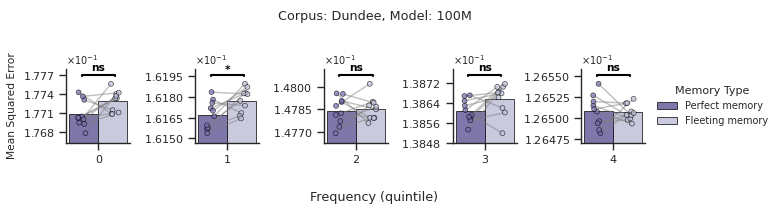

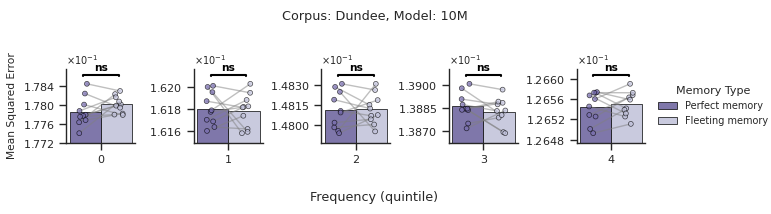

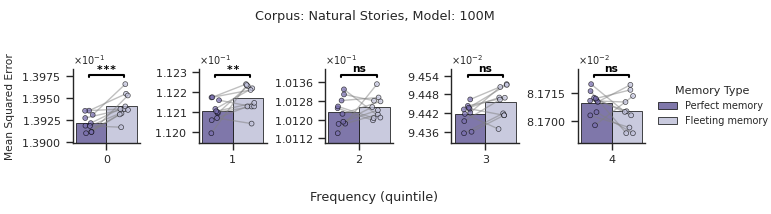

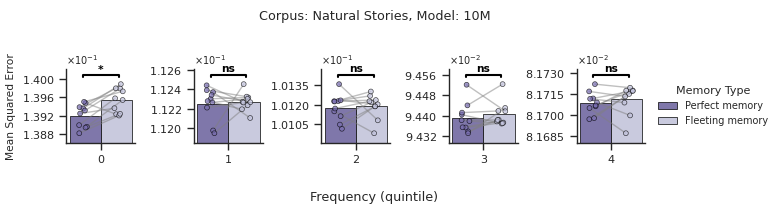

In [55]:
# import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# import seaborn as sns
# from tqdm.auto import tqdm
# import numpy as np
# import pandas as pd
# import
from matplotlib.ticker import ScalarFormatter
# Assume necessary functions like connect_dots_ib, annotate_given_colid_ib_gen, save_matplot_fig are defined
# Assume model_quintile_analysis_df is loaded and populated correctly

sse_or_mse = "MSE_mean"
save_plot=True
fmt='png'

# Get unique corpus IDs and model sizes
corpus_ids = model_quintile_analysis_df["CorpusID"].unique()
model_sizes = model_quintile_analysis_df["Dataset"].unique()
num_quintiles = model_quintile_analysis_df["QuintilesA3"].nunique() # Get count based on data

# <<< CHANGE: Adjusted font_scale for paper context if needed >>>
with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=.8): # Using 'paper' context
    for i, corpus_id in tqdm(enumerate(corpus_ids), total=len(corpus_ids)):
        for j, model_size in tqdm(enumerate(model_sizes), total=len(model_sizes), leave=False):

            fig, axes = plt.subplots(1, num_quintiles, figsize=(8,2))
            fig.subplots_adjust(left=0.1, right=0.9, bottom=0.2, top=0.85, wspace=0.4)

            fig.suptitle(f"Corpus: {corpus_id}, Model: {model_size}",  y=0.98)
            fig.supxlabel("Frequency (quintile)")
            # fig.supylabel("Mean Squared Error (MSE)" if sse_or_mse == "MSE_mean" else "Sum Squared Error (SSE)", x=0.02)

            unique_quintiles = sorted(model_quintile_analysis_df["QuintilesA3"].unique()) # Ensure consistent order

            for k, quintile in tqdm(enumerate(unique_quintiles), total=num_quintiles, leave=False):
                ax = axes[k]

                subset = model_quintile_analysis_df[
                    (model_quintile_analysis_df["CorpusID"] == corpus_id) &
                    (model_quintile_analysis_df["Dataset"] == model_size) &
                    (model_quintile_analysis_df["QuintilesA3"] == quintile)
                ].copy() # IMPORTANT: work on a copy

                # Convert QuintilesA3 to string for categorical plotting AFTER filtering
                subset["QuintilesA3"] = subset.QuintilesA3.astype(str)

                # --- START OF CHANGE ---
                # Define the mapping for the labels
                label_map = {"Unmasked": "Perfect memory", "Masked": "Fleeting memory"}

                # Apply the mapping to the 'MaskType' column
                # Using .replace is often safer than .map if there might be unexpected values
                subset["MaskType"] = subset["MaskType"].replace(label_map)

                # Define a new palette order if needed, matching the new labels
                # Check the default order or explicitly set it if seaborn changes it
                # Assuming 'Perfect memory' (Unmasked) comes first, then 'Fleeting memory' (Masked)
                # The palette 'Purples_r' goes from light to dark. Unmasked was dark, Masked was light.
                # So 'Perfect memory' should be dark, 'Fleeting memory' should be light.
                # Seaborn might sort hue labels alphabetically, so we might need to force order.
                hue_order = ["Perfect memory", "Fleeting memory"]
                palette_map = {"Perfect memory": sns.color_palette("Purples_r", 2)[0], # Darker purple
                               "Fleeting memory": sns.color_palette("Purples_r", 2)[1]} # Lighter purple
                # --- END OF CHANGE ---


                # Plotting calls - use hue_order and palette_map
                sns.barplot(x="QuintilesA3", y=sse_or_mse, hue="MaskType", data=subset, ax=ax,
                            # palette="Purples_r", # Use palette_map instead
                            palette=palette_map,
                            hue_order=hue_order, # Ensure consistent order
                            errorbar=None, width=0.7,
                            edgecolor='k', linewidth=0.5)

                sns.stripplot(x="QuintilesA3", y=sse_or_mse, hue="MaskType", data=subset, ax=ax,
                              dodge=True, alpha=0.7, linewidth=0.5, size=3.5,
                              # palette="Purples_r", # Use palette_map instead
                              palette=palette_map,
                              hue_order=hue_order, # Ensure consistent order
                              edgecolor='k')

                # ax.set_title(f"Quintile {quintile}", pad=5)
                ax.set_xlabel("")
                if k > 0:
                    ax.set_ylabel("")
                else:
                    # Ensure y-label appears correctly if needed, though supylabel is used
                    ax.set_ylabel("Mean Squared Error" if sse_or_mse == "MSE_mean" else "Sum Squared Error (SSE)")
                    ax.tick_params(axis='y', labelsize=8)


                # Ensure connect_dots_ib and annotate handle the renamed hue column
                # If they explicitly use "Unmasked"/"Masked", they might need adjustment.
                # Assuming they work based on the hue column's values directly.
                connect_dots_ib(ax, alpha=0.5, col='grey', linewidth=1.0)

                # Calculate smart y-limits
                min_y = subset[sse_or_mse].min()
                max_y = subset[sse_or_mse].max()
                data_range = max_y - min_y
                if data_range < 1e-9: # Handle very small ranges
                   data_range = max_y * 0.1 if max_y > 1e-9 else 0.1
                if data_range == 0: # Handle zero range
                    data_range = 0.1 # Assign a small default range

                buffer = data_range * 0.2
                ax.set_ylim(min_y - buffer, max_y + buffer * 1.5) # Increased top buffer slightly for annotations

                # Apply tick locator
                ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4, prune='both'))

                # Add scientific notation formatter
                formatter = ScalarFormatter(useMathText=True)
                formatter.set_scientific(True)
                formatter.set_powerlimits((-1,1)) # Adjust power limits if needed
                ax.yaxis.set_major_formatter(formatter)
                # ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0)) # Alternative, often simpler

                annotate_given_colid_ib_gen(ax, subset, y_frac=0.9, h_frac=0.02,
                                            x_col="QuintilesA3", pivot_col="MaskType", value_column=sse_or_mse)

                sns.despine(ax=ax, top=True, right=True)

                # Consistent tick label sizes
                ax.tick_params(axis='x', labelsize=8)
                ax.tick_params(axis='y', labelsize=8)


                # Legend handling
                if k != num_quintiles - 1:
                     current_legend = ax.get_legend()
                     if current_legend is not None:
                        current_legend.remove()
                else:
                    # --- START OF CHANGE ---
                    # Update the legend title
                    ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), title="Memory Type", # New title
                              # Pass the hue_order to ensure legend items match plots
                              handles=ax.get_legend_handles_labels()[0],
                              labels=hue_order,
                              frameon=False, title_fontsize='8', fontsize='7')
                    # --- END OF CHANGE ---


            plot_name = f"QuintilesA3_{corpus_id}_{model_size}_row_{sse_or_mse}_sciY_MemLabels.{fmt}" # Updated name
            # Use tight_layout before saving
            plt.tight_layout(rect=[0.03, 0.03, 1, 0.95]) # Adjust rect to prevent suptitle overlap if needed

            if save_plot:
                # Ensure the save function exists and works
                # save_matplot_fig(fig, plot_name, dpi = 1000, folders_path=f"quintilesspacy_{sse_or_mse}")
                # Fallback to standard savefig if needed:
                output_dir = f"quintilesspacy_{sse_or_mse}"
                import os
                if not os.path.exists(output_dir):
                    os.makedirs(output_dir)
                plt.savefig(os.path.join(output_dir, plot_name), dpi=300, bbox_inches='tight',format=fmt)

            # plt.close(fig) # Close the figure to free memory
            # plt.close('all') # Close any remaining figures if necessary

In [53]:
output_dir

'quintilesspacy_MSE_mean.pdf'

## Frequency x deltas 

Processing 2 corpus IDs and 2 model sizes...
Plotting Type: Absolute Difference
  Corpus: Dundee
    Model Size: 100M
Figure saved: /Users/Micha/Library/CloudStorage/OneDrive-UvA/Documents/Projects/in_progress/abishek_startingsmall/code/main/ss-llm/nanoGPT/eval/additional_analysis/reading_time_detailed/quintiles_difference_Absolute/AbsDiff_Dundee_100M_MSE_mean.pdf


/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/4145103412.py:60: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(subset["MaskType"]):
/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/4145103412.py:123: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='QuintilesA3', y=diff_column, data=df_plot, ax=ax,


    Model Size: 10M
Figure saved: /Users/Micha/Library/CloudStorage/OneDrive-UvA/Documents/Projects/in_progress/abishek_startingsmall/code/main/ss-llm/nanoGPT/eval/additional_analysis/reading_time_detailed/quintiles_difference_Absolute/AbsDiff_Dundee_10M_MSE_mean.pdf


/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/4145103412.py:60: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(subset["MaskType"]):
/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/4145103412.py:123: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='QuintilesA3', y=diff_column, data=df_plot, ax=ax,


  Corpus: Natural Stories
    Model Size: 100M
Figure saved: /Users/Micha/Library/CloudStorage/OneDrive-UvA/Documents/Projects/in_progress/abishek_startingsmall/code/main/ss-llm/nanoGPT/eval/additional_analysis/reading_time_detailed/quintiles_difference_Absolute/AbsDiff_Natural Stories_100M_MSE_mean.pdf


/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/4145103412.py:60: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(subset["MaskType"]):
/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/4145103412.py:123: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='QuintilesA3', y=diff_column, data=df_plot, ax=ax,


    Model Size: 10M
Figure saved: /Users/Micha/Library/CloudStorage/OneDrive-UvA/Documents/Projects/in_progress/abishek_startingsmall/code/main/ss-llm/nanoGPT/eval/additional_analysis/reading_time_detailed/quintiles_difference_Absolute/AbsDiff_Natural Stories_10M_MSE_mean.pdf


/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/4145103412.py:60: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(subset["MaskType"]):
/var/folders/3f/9ff50bqs1rd52fgjxbvj03n00000gq/T/ipykernel_15300/4145103412.py:123: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x='QuintilesA3', y=diff_column, data=df_plot, ax=ax,


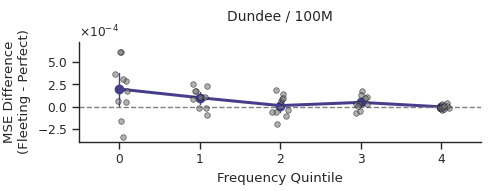

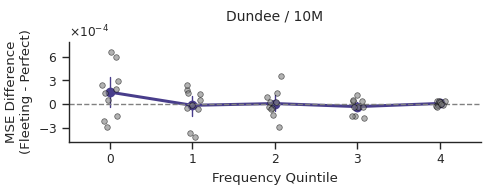

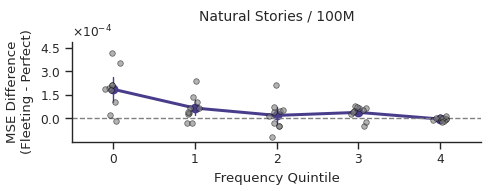

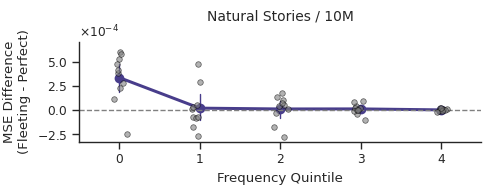

In [46]:
# --- Configuration ---
sse_or_mse = "MSE_mean" # Base metric column
use_relative_difference = False # <<< SWITCH: Set True for relative, False for absolute diff plot
perform_quintile_stats = False # Set True to calculate and show p-values per quintile
save_plot = True # <<< Make sure this is True if you want to save plots
output_folder_base_name = f"quintiles_difference" # Updated base name
# --- End Configuration ---

# Determine plot-specific settings based on the switch
if use_relative_difference:
    plot_type_suffix = "RelDiff"
    diff_column = 'Relative_Delta_MSE'
    y_label = f"Relative MSE Difference\n(Fleeting - Perfect) / Perfect"
    plot_title_suffix = "(Relative)"
    plot_color = 'teal'
    output_folder_name = f"{output_folder_base_name}_Relative"
else:
    plot_type_suffix = "AbsDiff"
    diff_column = 'Delta_MSE'
    y_label = f"MSE Difference\n(Fleeting - Perfect)"
    plot_title_suffix = ""
    plot_color = 'darkslateblue'
    output_folder_name = f"{output_folder_base_name}_Absolute"


# Create output directory if it doesn't exist
if save_plot and not os.path.exists(output_folder_name):
    os.makedirs(output_folder_name)

# --- Main Loop ---
# Assume model_quintile_analysis_df is loaded and populated correctly

corpus_ids = model_quintile_analysis_df["CorpusID"].unique()
model_sizes = model_quintile_analysis_df["Dataset"].unique()
num_quintiles = model_quintile_analysis_df["QuintilesA3"].nunique()

print(f"Processing {len(corpus_ids)} corpus IDs and {len(model_sizes)} model sizes...")
print(f"Plotting Type: {'Relative' if use_relative_difference else 'Absolute'} Difference")

label_map = {"Unmasked": "Perfect memory", "Masked": "Fleeting memory"}
hue_order = ["Perfect memory", "Fleeting memory"]

with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=1.0):
    for i, corpus_id in enumerate(corpus_ids):
        print(f"  Corpus: {corpus_id}")
        for j, model_size in enumerate(model_sizes):
            print(f"    Model Size: {model_size}")

            # 1. Filter data
            subset = model_quintile_analysis_df[
                (model_quintile_analysis_df["CorpusID"] == corpus_id) &
                (model_quintile_analysis_df["Dataset"] == model_size)
            ].copy()

            if subset.empty:
                 print(f"      Warning: No data found for {corpus_id}/{model_size}. Skipping.")
                 continue

            # 2. Apply MaskType Label Mapping
            if pd.api.types.is_categorical_dtype(subset["MaskType"]):
                 current_categories = subset["MaskType"].cat.categories
                 if any(cat in label_map for cat in current_categories):
                     rename_map = {k: v for k, v in label_map.items() if k in current_categories}
                     subset["MaskType"] = subset["MaskType"].cat.rename_categories(rename_map)
                 elif not all(cat in hue_order for cat in current_categories):
                     subset["MaskType"] = subset["MaskType"].astype(str).replace(label_map)
            else:
                 subset["MaskType"] = subset["MaskType"].replace(label_map)

            if not all(subset["MaskType"].isin(hue_order)):
                 print(f"      Warning: Expected MaskType labels not found after mapping for {corpus_id}/{model_size}. Found: {subset['MaskType'].unique()}. Skipping pivot.")
                 continue

            # 3. Pivot data using 'seed'
            try:
                df_pivoted = subset.pivot_table(
                    index=['QuintilesA3', 'seed'],
                    columns='MaskType',
                    values=sse_or_mse,
                    observed=False
                )

                if not all(mtype in df_pivoted.columns for mtype in hue_order):
                    missing = [m for m in hue_order if m not in df_pivoted.columns]
                    print(f"      Warning: Missing memory type(s) {missing} after pivoting for {corpus_id}/{model_size}. Skipping.")
                    continue

                df_pivoted = df_pivoted.dropna(subset=hue_order)

                if df_pivoted.empty:
                    print(f"      Warning: No complete pairs found after pivoting for {corpus_id}/{model_size}. Skipping plot.")
                    continue

            except Exception as e:
                print(f"      Error pivoting data for {corpus_id}/{model_size}: {e}")
                continue

            # 4. Calculate Differences
            df_pivoted['Delta_MSE'] = df_pivoted['Fleeting memory'] - df_pivoted['Perfect memory']
            perfect_mem_vals = df_pivoted['Perfect memory']
            delta_vals = df_pivoted['Delta_MSE']
            df_pivoted['Relative_Delta_MSE'] = np.where(
                np.abs(perfect_mem_vals) < 1e-9,
                np.nan,
                delta_vals / perfect_mem_vals
            )
            df_pivoted['Relative_Delta_MSE'] = df_pivoted['Relative_Delta_MSE'].replace([np.inf, -np.inf], np.nan)

            # Reset index
            df_diff = df_pivoted.reset_index()

            # 5. Filter out NaNs/Infs *for the column being plotted*
            df_plot = df_diff.dropna(subset=[diff_column]).copy()

            if df_plot.empty:
                 print(f"      Skipping plot for {corpus_id}/{model_size}: No valid data points found for '{diff_column}'.")
                 continue

            # --- Create Single Plot (Absolute or Relative) ---
            fig, ax = plt.subplots(1, 1, figsize=(5, 2))

            # Point plot for mean difference and CI
            sns.pointplot(x='QuintilesA3', y=diff_column, data=df_plot, ax=ax,
                          color=plot_color,
                        #   errorbar=('ci', 95),
                        #   capsize=0.1,
                          err_kws={'linewidth': 1},
                          markers='o',
                          linestyles='-',
                          join=True)

            # Strip plot for individual differences (overlay)
            sns.stripplot(x='QuintilesA3', y=diff_column, data=df_plot, ax=ax,
                          color='grey', alpha=0.6, size=4, jitter=0.1,
                          edgecolor='k', linewidth=0.5)

            ax.axhline(0, color='grey', linestyle='--', linewidth=1)
            ax.set_xlabel("Frequency Quintile")
            ax.set_ylabel(y_label)
            ax.set_title(f"{corpus_id} / {model_size} {plot_title_suffix}".strip(), fontsize=10, pad=15)

            # --- Apply Y-axis Formatting ---
            if use_relative_difference:
                # Use Percentage formatter for relative plot
                ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
            else:
                # Use Scientific Notation formatter for absolute plot
                formatter = mticker.ScalarFormatter(useMathText=True)
                formatter.set_scientific(True)
                # Force scientific notation for exponents outside 0 (like 10^-1, 10^-2, etc.)
                # Use (0,0) to mimic the style in the original individual plots
                formatter.set_powerlimits((0, 0))
                ax.yaxis.set_major_formatter(formatter)
            # --- End Y-axis Formatting ---

            # Ensure reasonable number of ticks AFTER applying formatter
            ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, prune='both'))


            # Add Significance Annotations (Optional)
            max_y_overall = -np.inf
            temp_perform_quintile_stats = perform_quintile_stats

            if temp_perform_quintile_stats:
                quintiles = sorted(df_plot['QuintilesA3'].unique())
                y_max_plot_lim = ax.get_ylim()[1] # Get limit after potential formatter adjustment
                # Estimate offset based on axis range, handle potential large/small numbers
                axis_range = ax.get_ylim()[1] - ax.get_ylim()[0]
                base_offset = axis_range * 0.05 if axis_range > 1e-9 else y_max_plot_lim * 0.05


                for k, quintile in enumerate(quintiles):
                    diff_values = df_plot[df_plot['QuintilesA3'] == quintile][diff_column].dropna()

                    # Determine max y for this quintile based on CI and strip points
                    q_data_max = diff_values.max() if not diff_values.empty else -np.inf
                    mean_val = diff_values.mean()
                    stderr = diff_values.std() / np.sqrt(len(diff_values)) if len(diff_values) > 0 else 0
                    ci_upper = mean_val + 1.96 * stderr if not np.isnan(stderr) and len(diff_values) > 0 else mean_val

                    q_elem_max_y = max(q_data_max if not np.isinf(q_data_max) else -np.inf,
                                       ci_upper if not np.isnan(ci_upper) else -np.inf)
                    if np.isnan(q_elem_max_y) or np.isinf(q_elem_max_y): q_elem_max_y = 0

                    # Add small margin based on magnitude if possible, otherwise use base_offset
                    margin = abs(q_elem_max_y * 0.05) if abs(q_elem_max_y) > 1e-9 else base_offset
                    anno_y_pos = q_elem_max_y + margin + base_offset

                    if len(diff_values) >= 2:
                        try:
                            res = bootstrap_analysis(diff_values.values)
                            p_value = res['bootstrap-t-test p_value']
                            stars = get_asterisk_map(p_value)
                            ax.text(k, anno_y_pos, stars, ha='center', va='bottom', fontsize=9, weight='bold')
                            max_y_overall = max(max_y_overall, anno_y_pos)

                        except NameError as e:
                            print(f"      Warning: Required function for stats/annotation not found: {e}. Skipping annotations.")
                            ax.text(k, anno_y_pos, "?", ha='center', va='bottom', fontsize=9)
                            max_y_overall = max(max_y_overall, anno_y_pos)
                            temp_perform_quintile_stats = False # Stop trying
                        except Exception as e:
                            print(f"      Error during bootstrap/annotation for Q{quintile}: {e}")
                            ax.text(k, anno_y_pos, "err", ha='center', va='bottom', fontsize=8)
                            max_y_overall = max(max_y_overall, anno_y_pos)
                    else:
                         ax.text(k, anno_y_pos, 'n<2', ha='center', va='bottom', fontsize=8)
                         max_y_overall = max(max_y_overall, anno_y_pos)
            else:
                 # Find max y based on data/CIs only if not annotating
                 max_y_overall = df_plot[diff_column].max()
                 for k, quintile in enumerate(sorted(df_plot['QuintilesA3'].unique())):
                     diff_values = df_plot[df_plot['QuintilesA3'] == quintile][diff_column].dropna()
                     if not diff_values.empty:
                        mean_val = diff_values.mean()
                        stderr = diff_values.std() / np.sqrt(len(diff_values)) if len(diff_values) > 0 else 0
                        ci_upper = mean_val + 1.96 * stderr if not np.isnan(stderr) else mean_val
                        max_y_overall = max(max_y_overall if not np.isnan(max_y_overall) and not np.isinf(max_y_overall) else -np.inf,
                                            ci_upper if not np.isnan(ci_upper) else -np.inf)


            # Adjust y-limits
            current_ylim = ax.get_ylim()
            if max_y_overall is not None and not np.isinf(max_y_overall) and not np.isnan(max_y_overall):
                 # Add slightly more margin maybe
                 final_top_limit = max(current_ylim[1], max_y_overall) * 1.10
                 ax.set_ylim(current_ylim[0], final_top_limit)
            elif current_ylim[1] is not None and not np.isnan(current_ylim[1]) and abs(current_ylim[1]) > 1e-9 :
                 ax.set_ylim(current_ylim[0], current_ylim[1] * 1.10)


            sns.despine(ax=ax)
            plt.tight_layout()

            # Save the plot
            if save_plot:
                plot_name = f"{plot_type_suffix}_{corpus_id}_{model_size}_{sse_or_mse}.pdf"
                save_matplot_fig(fig, plot_name, dpi = 300, folders_path=output_folder_name) #f"quintilesspacy_{sse_or_mse}")
                save_path = os.path.join(output_folder_name, plot_name)
                # print(f"      Saving {plot_type_suffix} plot to: {save_path}")
                fig.savefig(save_path, dpi=300, bbox_inches='tight',format='pdf')


In [45]:
output_folder_name

'quintiles_difference_MSE_mean_Absolute'

## Old plots 

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

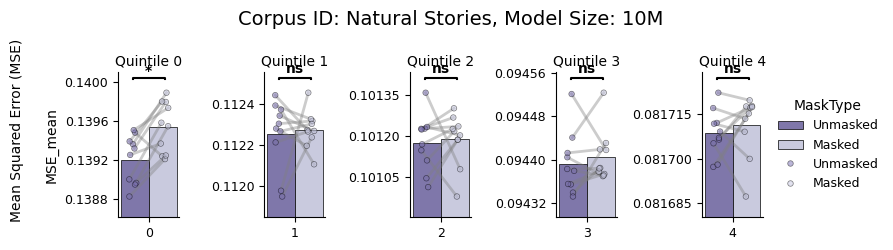

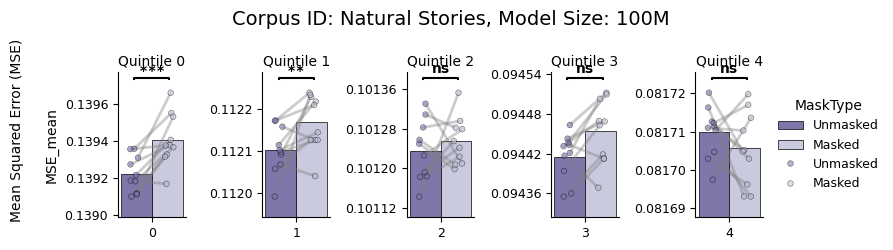

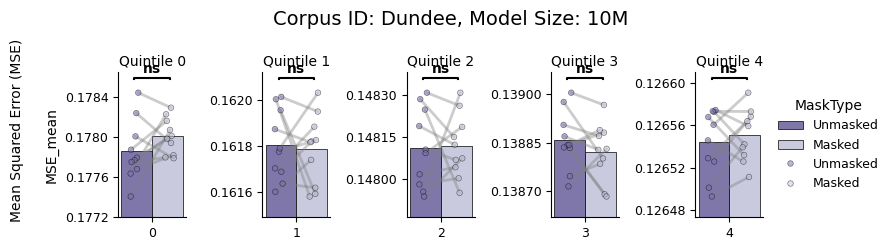

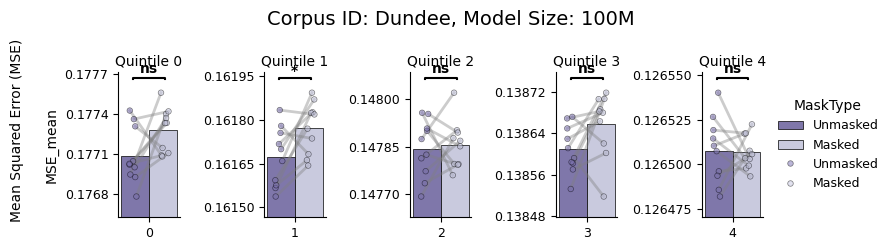

In [ ]:
sse_or_mse = "MSE_mean"
save_plot = False
num_quintiles = model_quintile_analysis_df["QuintilesA3"].nunique()

# <<< REMOVED: Seaborn context managers >>>
# with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=.8):
for i, corpus_id in tqdm(enumerate(["Natural Stories", "Dundee"])):
    for j, model_size in tqdm(enumerate(["10M", "100M"])):

        # <<< CHANGE: Adjusted figsize slightly, might need tuning >>>
        fig, axes = plt.subplots(1, num_quintiles, figsize=(9, 2.5))
        # <<< CHANGE: Adjust spacing, may need tuning >>>
        fig.subplots_adjust(left=0.08, right=0.9, bottom=0.2, top=0.8, wspace=0.4)

        # <<< CHANGE: Larger suptitle font, adjusted y >>>
        fig.suptitle(f"Corpus ID: {corpus_id}, Model Size: {model_size}", fontsize=14, y=0.98)
        # <<< CHANGE: Adjusted supylabel x position >>>
        fig.supylabel("Mean Squared Error (MSE)" if sse_or_mse == "MSE_mean" else "Sum Squared Error (SSE)", x=0.01, fontsize=10)

        for k, quintile in tqdm(enumerate(model_quintile_analysis_df["QuintilesA3"].unique()), leave=False):
            ax = axes[k]

            subset = model_quintile_analysis_df[
                (model_quintile_analysis_df["CorpusID"] == corpus_id) &
                (model_quintile_analysis_df["Dataset"] == model_size) &
                (model_quintile_analysis_df["QuintilesA3"] == quintile)
            ].copy()
            subset["QuintilesA3"] = subset.QuintilesA3.astype(str)

            # Plotting calls
            # <<< CHANGE: Ensure barplot parameters match example >>>
            sns.barplot(x="QuintilesA3", y=sse_or_mse, hue="MaskType", data=subset, ax=ax,
                        palette="Purples_r", errorbar=None, width=0.7,
                        edgecolor='k', linewidth=0.5)

            # <<< CHANGE: Ensure stripplot parameters match example >>>
            sns.stripplot(x="QuintilesA3", y=sse_or_mse, hue="MaskType", data=subset, ax=ax,
                          dodge=True, alpha=0.5, linewidth=0.5, size=4, # Changed alpha/size
                          palette="Purples_r", edgecolor='k')

            # <<< CHANGE: Adjusted title fontsize/pad >>>
            ax.set_title(f"Quintile {quintile}", fontsize=10, pad=5)
            ax.set_xlabel("")
            if k > 0:
                ax.set_ylabel("")
            else:
                # Keep first y-label, ensure size is reasonable
                ax.tick_params(axis='y', labelsize=9) # Slightly larger tick labels
                ax.set_ylabel(ax.get_ylabel(), fontsize=10) # Set label fontsize if needed


            # <<< CHANGE: Ensure connect_dots parameters match example >>>
            connect_dots_ib(ax, alpha=0.4, col='grey', linewidth=2.0) # Changed alpha/linewidth

            # <<< CHANGE: Use exact symmetric y-limit calculation from example >>>
            min_y = subset[sse_or_mse].min()
            max_y = subset[sse_or_mse].max()
            ydelta = max_y - min_y
            if ydelta < 1e-9: # Handle zero range
               ydelta = max_y * 0.1 if max_y > 1e-9 else 0.1
            delta_per = 0.2 # Explicit 20% buffer
            ax.set_ylim(min_y - ydelta * delta_per, max_y + ydelta * delta_per) # Symmetric buffer


            # Apply tick locator
            ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4, prune='both'))

            # <<< REMOVED: Scientific notation formatter >>>
            # formatter = ScalarFormatter(useMathText=True)
            # ...
            # ax.yaxis.set_major_formatter(formatter)
            # ax.ticklabel_format(...)

            # <<< CHANGE: Adjust annotation parameters to match example >>>
            annotate_given_colid_ib_gen(ax, subset, y_frac=0.95, h_frac=0.01, # Adjusted params
                                        x_col="QuintilesA3", pivot_col="MaskType", value_column=sse_or_mse)

            sns.despine(ax=ax, top=True, right=True)

            # Consistent tick label sizes
            ax.tick_params(axis='x', labelsize=9) # Slightly larger tick labels
            ax.tick_params(axis='y', labelsize=9) # Ensure y tick size consistency


            if k != num_quintiles - 1:
                 if ax.get_legend() is not None:
                    ax.get_legend().remove()
            else:
                # <<< CHANGE: Adjust legend position and fonts >>>
                ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5), title="MaskType", # Adjusted anchor slightly
                          frameon=False, title_fontsize='10', fontsize='9') # Adjusted fonts


        # <<< REMOVED: plt.tight_layout() - Use subplots_adjust instead >>>
        plt.tight_layout()

        plot_name = f"QuintilesA3_{corpus_id}_{model_size}_row_{sse_or_mse}_styleMatch.png" # Updated name
        if save_plot:
            # Save the figure using the custom function
            save_matplot_fig(fig, plot_name, dpi = 300, folders_path=f"quintilesspacy_{sse_or_mse}") # Use lower DPI if 1000 not needed
            plt.close(fig) # Close figure after saving



# Over/underprediction

In [41]:
#For each of the model in the results - Calculate MSE for each of the quintile
model_quintile_analysis_underover_df = None
from tqdm.auto import tqdm

for row in tqdm(model_list_df.to_dict(orient="records")):
    model_predicts = pd.read_sql_query(f"SELECT * FROM RTModelPredict WHERE ModelID={row['ModelID']}", conn)

    model_predicts["delta"] = model_predicts["PredictedLogRT"] - model_predicts["LogRT"]
    model_predicts["delta_squared"] = model_predicts["delta"] ** 2
    model_predicts["underover"] = np.where(model_predicts["delta"] > 0, "Overpredicted", "Underpredicted")



    model_predicts = model_predicts.merge(story_words_df[["StoryWordID", "WordUID", "CorpusID"]], on="StoryWordID", how="left")
    model_predicts = model_predicts.merge(words_df[["WordUID", "QuintilesA3"]], on="WordUID", how="left")

    model_predicts_grouped = model_predicts[["ModelID", "CorpusID", "QuintilesA3", "underover", 
                                             "delta_squared"]].groupby(["ModelID", "CorpusID", "underover", "QuintilesA3"]).agg({"delta_squared": ["mean", "std", "sum", "count"]}).reset_index()
    model_predicts_grouped.columns = ["ModelID", "CorpusID", "underover", "QuintilesA3", "MSE_mean", "MSE_std", "SSE", "count"]

    if model_quintile_analysis_underover_df is None:
        model_quintile_analysis_underover_df = model_predicts_grouped
    else:
        model_quintile_analysis_underover_df = pd.concat([model_quintile_analysis_underover_df, model_predicts_grouped], ignore_index=True)

model_quintile_analysis_underover_df




  0%|          | 0/40 [00:00<?, ?it/s]

,ModelID,CorpusID,underover,QuintilesA3,MSE_mean,MSE_std,SSE,count
0,8465733,1,Overpredicted,0,0.066449,0.102225,975.940680,14687
1,8465733,1,Overpredicted,1,0.059969,0.094820,1536.653512,25624
2,8465733,1,Overpredicted,2,0.058823,0.091945,1570.155220,26693
3,8465733,1,Overpredicted,3,0.055094,0.088347,2457.432673,44604
4,8465733,1,Overpredicted,4,0.048665,0.080783,18634.487022,382912
...,...,...,...,...,...,...,...,...
795,6839427,2,Underpredicted,0,0.187917,0.242601,1320.493942,7027
796,6839427,2,Underpredicted,1,0.174830,0.238576,1198.284736,6854
797,6839427,2,Underpredicted,2,0.159579,0.232905,1343.813673,8421
798,6839427,2,Underpredicted,3,0.146841,0.220647,1642.562414,11186


In [42]:
# model_quintile_analysis_underover_df = pd.read_csv("/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/additional_analysis/model_quintile_analysis_df_spacylogprobs_underover.csv")
# model_quintile_analysis_underover_df = model_quintile_analysis_underover_df.copy()

model_quintile_analysis_underover_df = model_quintile_analysis_underover_df.merge(model_list_df, on="ModelID", how="left")
#model_quintile_analysis_underover_df

#PREPARE DATA BY Converting Corpus ID 1 to Natural Stories and 2 to Dundee
# Convert Dataset to babylm_full_bpe_8k to 10M and babylm_full_bpe_100M_8k to 100M
# Convert MaskType Non to Unmasked and exponential_new to Masked
model_quintile_analysis_underover_df["CorpusID"] = model_quintile_analysis_underover_df["CorpusID"].replace({1: "Natural Stories", 2: "Dundee"})
model_quintile_analysis_underover_df["Dataset"] = model_quintile_analysis_underover_df["Dataset"].replace({"babylm_full_bpe_8k": "10M", "babylm_full_bpe_100M_8k": "100M"})
model_quintile_analysis_underover_df["MaskType"] = model_quintile_analysis_underover_df["MaskType"].replace({"Non": "Unmasked", "exponential_new": "Masked"})

model_quintile_analysis_underover_df["QuintilesA3"] = pd.Categorical(model_quintile_analysis_underover_df["QuintilesA3"], ordered=True)
model_quintile_analysis_underover_df["Dataset"] = pd.Categorical(model_quintile_analysis_underover_df["Dataset"], ordered=True)
model_quintile_analysis_underover_df["underover"] = pd.Categorical(model_quintile_analysis_underover_df["underover"], ordered=True, categories=["Overpredicted", "Underpredicted"])
#Make MaskType as categorical with order Unmasked, Masked
model_quintile_analysis_underover_df["MaskType"] = pd.Categorical(model_quintile_analysis_underover_df["MaskType"], ordered=True, categories=["Unmasked", "Masked"])
model_quintile_analysis_underover_df = model_quintile_analysis_underover_df.sort_values(by=["QuintilesA3", "CorpusID", "Dataset", "MaskType", "Seed"])

model_quintile_analysis_underover_df = model_quintile_analysis_underover_df.rename(columns={"Seed":"seed"})


model_quintile_analysis_underover_df

,ModelID,CorpusID,underover,QuintilesA3,MSE_mean,MSE_std,SSE,count,BatchSize,Dataset,seed,MaskType
10,8465733,Dundee,Overpredicted,0,0.166407,0.271581,1095.791161,6585,32,100M,9,Unmasked
15,8465733,Dundee,Underpredicted,0,0.187434,0.242244,1328.158730,7086,32,100M,9,Unmasked
90,8465604,Dundee,Overpredicted,0,0.166088,0.271286,1097.839293,6610,32,100M,42,Unmasked
95,8465604,Dundee,Underpredicted,0,0.187304,0.241140,1322.556035,7061,32,100M,42,Unmasked
170,8465611,Dundee,Overpredicted,0,0.165895,0.271314,1096.567067,6610,32,100M,466,Unmasked
...,...,...,...,...,...,...,...,...,...,...,...,...
629,6839428,Natural Stories,Underpredicted,4,0.127520,0.335719,35272.576158,276604,32,10M,6747,Masked
704,6839431,Natural Stories,Overpredicted,4,0.048617,0.080736,18612.214739,382833,32,10M,11111,Masked
709,6839431,Natural Stories,Underpredicted,4,0.127433,0.335535,35267.547260,276753,32,10M,11111,Masked
784,6839427,Natural Stories,Overpredicted,4,0.048607,0.080731,18610.885097,382886,32,10M,46674,Masked


In [44]:
ROOT

'/Users/Micha/Library/CloudStorage/OneDrive-UvA/Documents/Projects/in_progress/abishek_startingsmall/code/main/ss-llm/nanoGPT'

In [45]:
if micha:
    analysis_root=Path(ROOT) / 'eval/additional_analysis/'
    over_underpath=analysis_root/"model_quintile_analysis_df_spacylogprobs_underover.csv"
    # over_underpath='/Users/Micha/Library/CloudStorage/OneDrive-UvA/Documents/Projects/in_progress/abishek_startingsmall/code/main/ss-llm/nanoGPT/eval/additional_analysis/model_quintile_analysis_df_spacylogprobs.csv'
else:
    analysis_root=Path(ROOT) / 'eval/additional_analysis/'
    over_underpath=analysis_root/"model_quintile_analysis_df_spacylogprobs_underover.csv"
    over_underpath="/home/abishekthamma/PycharmProjects/masters_thesis/ss-llm/nanoGPT/eval/additional_analysis/model_quintile_analysis_df_spacylogprobs_underover.csv"
    # model_quintile_analysis_df = pd

model_quintile_analysis_underover_df = pd.read_csv(over_underpath)

# model_quintile_analysis_underover_df

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

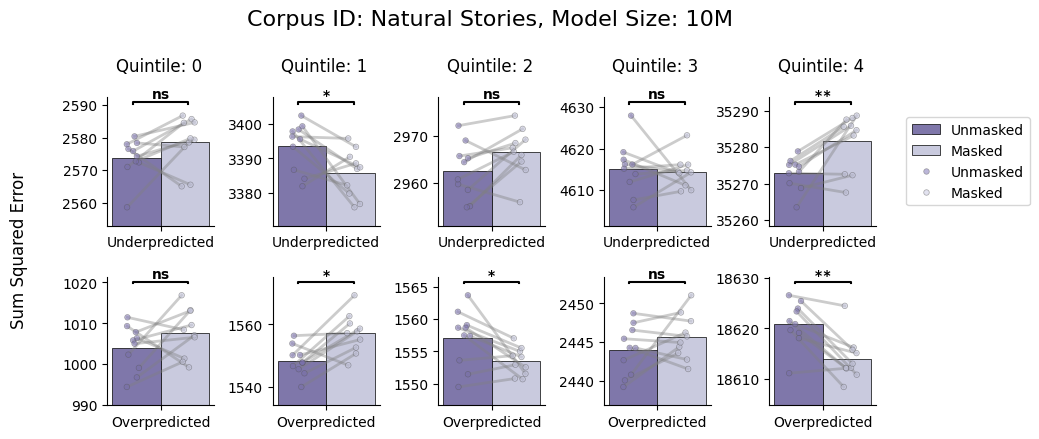

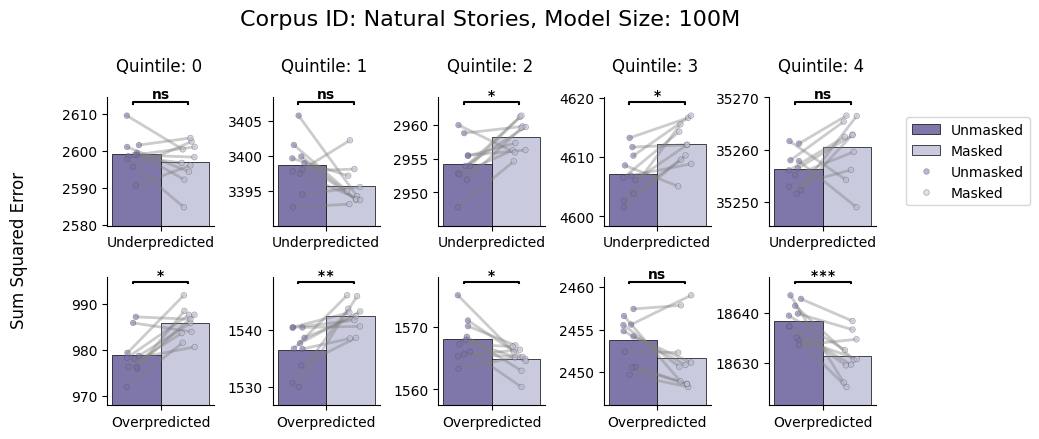

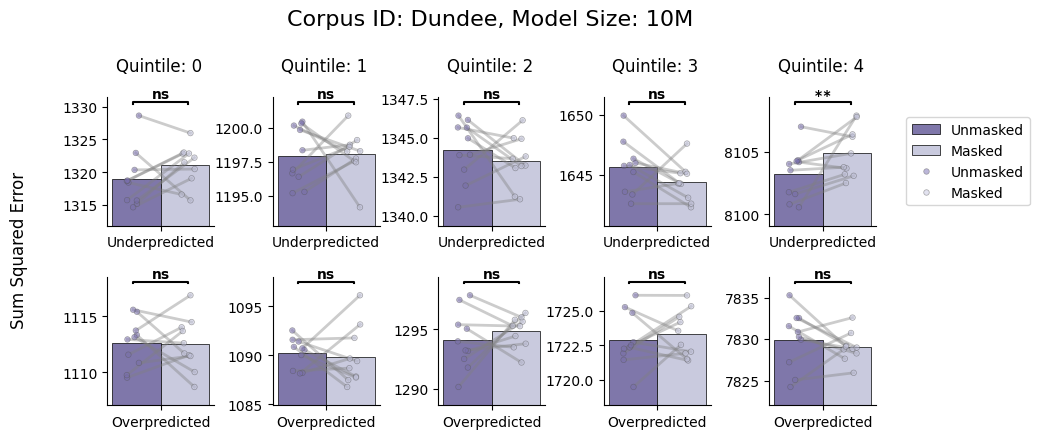

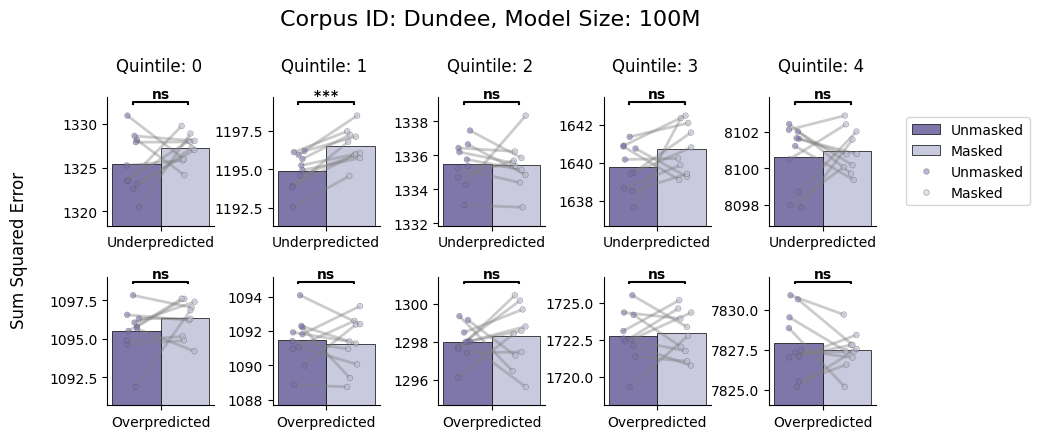

In [47]:
#4 Plots 2,2 Where 2 are for Corpus 1 and 2 are for Corpus 2. Each Having 10M and 100M

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
# fig, axes = plt.subplots(4, 1, figsize=(16, 8), sharex=True)
import numpy as np
#Create 4x1 Subfigures and within each, 11 subplots for each POSTag
sse_or_mse = "SSE"
for i, corpus_id in tqdm(enumerate(["Natural Stories", "Dundee"])):
    for j, model_size in tqdm(enumerate(["10M", "100M"])):
        # ax = axes[i, j]
        # index = i * 2 + j
        # ax = axes[index]
        #ax = fig.add_subplot(2, 2, index + 1)
        #Create 11 plots for each POSTag
        # fig, axes = plt.subplots(2, 3, figsize=(16, 8))
        # fig.subplots_adjust(hspace=0.4, wspace=0.6)
        # fig.suptitle(f"Corpus ID: {corpus_id}, Model Size: {model_size}", fontsize=16)
        fig = plt.figure(figsize=(8, 4))
        subfigs = fig.subfigures(1, 5, wspace=0.2, hspace=0.2)
        fig.suptitle(f"Corpus ID: {corpus_id}, Model Size: {model_size}", fontsize=16, y=1.1)
        for k, quintile in tqdm(enumerate(model_quintile_analysis_underover_df["QuintilesA3"].unique())):
            if k == 0:
                fig.supylabel("Sum Squared Error", x=-0.1)  if sse_or_mse == "SSE" else fig.supylabel("Mean Squared Error", x=-0.1)
            axes = subfigs[k].subplots(2, 1)
            subfigs[k].subplots_adjust(hspace=0.4, wspace=0.6)
            subfigs[k].suptitle(f"Quintile: {quintile}")
            for l, uop in enumerate(["Underpredicted", "Overpredicted"]):
                ax = axes[l]
                
                subset = model_quintile_analysis_underover_df[(model_quintile_analysis_underover_df["CorpusID"] == corpus_id) & (model_quintile_analysis_underover_df["Dataset"] == model_size) & (model_quintile_analysis_underover_df["QuintilesA3"] == quintile) & (model_quintile_analysis_underover_df["underover"] == uop)].copy()
                #Make POSTag as not categorical
                subset["QuintilesA3"] = subset.QuintilesA3.astype(str)
                subset["underover"] = subset.underover.astype(str)
                sns.barplot(x="underover", y=sse_or_mse, hue="MaskType", data=subset, ax=ax, errorbar=None,palette="Purples_r", width=0.7, edgecolor='k', linewidth=0.5)
                sns.stripplot(x="underover", y=sse_or_mse, hue="MaskType",  data=subset, ax=ax, dodge=True, alpha=0.5,palette="Purples_r", linewidth=0.5, size=4)
                # ax.set_title(f"POSTag: {postag}")
                
                ax.set_xlabel("")
                # if k == 0 or k == 6:
                #     ax.set_ylabel("Sum Squared Error") if sse_or_mse == "SSE" else ax.set_ylabel("Mean Squared Error")
                # else:
                ax.set_ylabel("")
                
                connect_dots_ib(ax, alpha=0.4, col='grey', linewidth=2)
                # Annotate the plot with significance stars
                #Find Max and Min Y limit as measure of max and and min delta
                max_y = subset[sse_or_mse].max()
                min_y = subset[sse_or_mse].min()
                
                ydelta = max_y - min_y

                delta_per = 0.2
                ax.set_ylim(min_y - ydelta * delta_per, max_y + ydelta * delta_per)

                annotate_given_colid_ib_gen(ax, subset, y_frac=0.95, h_frac=0.01, x_col="underover", pivot_col="MaskType", value_column=sse_or_mse)
                sns.despine(ax=ax, top=True, right=True)
                # ax.get_legend().remove()
                if k!=4:
                    ax.get_legend().remove()
                else:
                    if l == 0:
                        ax.legend(loc="center right", bbox_to_anchor=(2.5, 0.5))
                    else:
                        ax.get_legend().remove()
                    #ax.legend(loc="center right", bbox_to_anchor=(2.5, 0.5))
            #fig.delaxes(axes[1, 3])  # Remove the last empty subplot
        
        
        # Save the figure
        plot_name = f"QuintilesA3{corpus_id}_{model_size}_full_corpus_{sse_or_mse}.png"
        # save_matplot_fig(fig, plot_name, dpi = 1000, folders_path=f"Quintile_Spacy_UnderOver_{sse_or_mse}")